# ORBIT-2 Data Inspector
Inspect and visualize `.npz` files from the ORBIT-2 dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Configuration
Set the path to the `.npz` file you want to inspect.

In [2]:
FILE_PATH = "ERA5/0.25_deg/train/2016_0.npz"  # <-- change this
TIME_IDX  = 0                                 # time index to plot

## Load file

In [3]:
data = np.load(FILE_PATH)
print(f"Loaded: {FILE_PATH}")
for var_name in data.files:
    print(f"Variables: {var_name}")

Loaded: ERA5/0.25_deg/train/2016_0.npz
Variables: land_sea_mask
Variables: landcover
Variables: latitude
Variables: orography
Variables: 10m_u_component_of_wind
Variables: 10m_v_component_of_wind
Variables: 2m_temperature_max
Variables: 2m_temperature_min
Variables: 2m_temperature
Variables: sea_surface_temperature
Variables: surface_pressure
Variables: total_precipitation_24hr
Variables: volumetric_soil_water_layer_1
Variables: geopotential_50
Variables: geopotential_100
Variables: geopotential_150
Variables: geopotential_200
Variables: geopotential_250
Variables: geopotential_300
Variables: geopotential_400
Variables: geopotential_500
Variables: geopotential_600
Variables: geopotential_700
Variables: geopotential_850
Variables: geopotential_925
Variables: geopotential_1000
Variables: specific_humidity_50
Variables: specific_humidity_100
Variables: specific_humidity_150
Variables: specific_humidity_200
Variables: specific_humidity_250
Variables: specific_humidity_300
Variables: specif

## Time metadata

In [4]:
for key in ["days_of_year", "time_of_day", "hrs_each_step", "num_steps_per_shard"]:
    if key in data.files:
        print(f"{key}: {np.unique(data[key])}")

days_of_year: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
time_of_day: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
hrs_each_step: [1]
num_steps_per_shard: [438]


## Variable summary table

In [5]:
col_w = max(len(v) for v in data.files)
header = f"{'Variable':<{col_w}}  {'Shape':<20}  {'Min':>14}  {'Max':>14}  {'Dtype':<10}"
print("=" * len(header))
print(header)
print("=" * len(header))
for var_name in data.files:
    v = data[var_name]
    print(f"{var_name:<{col_w}}  {str(v.shape):<20}  {v.min():>14.6g}  {v.max():>14.6g}  {str(v.dtype):<10}")
print("=" * len(header))

Variable                       Shape                            Min             Max  Dtype     
land_sea_mask                  (438, 1, 720, 1440)                0               1  float32   
landcover                      (438, 1, 720, 1440)                1              19  float32   
latitude                       (438, 1, 720, 1440)           -89.75              90  float32   
orography                      (438, 1, 720, 1440)                0            6407  float32   
10m_u_component_of_wind        (438, 1, 720, 1440)         -33.8841         32.5801  float32   
10m_v_component_of_wind        (438, 1, 720, 1440)          -32.666         28.3651  float32   
2m_temperature_max             (438, 1, 720, 1440)          221.418         319.159  float32   
2m_temperature_min             (438, 1, 720, 1440)          219.469           307.3  float32   
2m_temperature                 (438, 1, 720, 1440)          219.469         319.159  float32   
sea_surface_temperature        (438, 1, 

## Plot variables
Set `PLOT_VARS` to a list of variable names to visualize.

In [6]:
PLOT_VARS = ["2m_temperature"]  # <-- change this

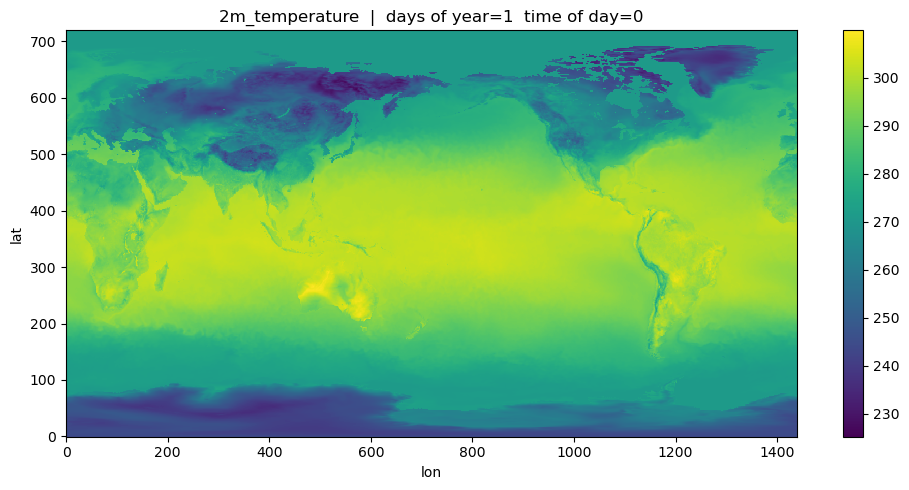

In [7]:
def get_slice(arr, time):
    """Extract 2D (lat, lon) slice at given time index."""
    img = arr[time] if arr.ndim >= 3 else arr
    img = np.squeeze(img)
    if img.ndim != 2:
        img = img.reshape(img.shape[-2], img.shape[-1])
    return img

doy = int(data["days_of_year"][TIME_IDX, 0, 0, 0]) if "days_of_year" in data.files else "?"
tod = int(data["time_of_day"][TIME_IDX, 0, 0, 0])  if "time_of_day"  in data.files else "?"

for var_name in PLOT_VARS:
    if var_name not in data.files:
        print(f"Warning: '{var_name}' not found, skipping.")
        continue

    arr = data[var_name]
    if arr.ndim < 2:
        print(f"Warning: '{var_name}' has shape {arr.shape}, need at least 2D, skipping.")
        continue

    img = get_slice(arr, TIME_IDX)

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(img, origin="lower", aspect="auto", interpolation="none",
                   vmin=np.nanmin(img), vmax=np.nanmax(img))
    fig.colorbar(im, ax=ax)
    ax.set_title(f"{var_name}  |  days of year={doy}  time of day={tod}")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    plt.tight_layout()
    plt.show()